# **Classification supervisée d’images :**  
*CNN : VGG16 en classification supervisée par transfert learning*  
et  
*Vision Transformer : ViT en classification supervisée par transfert learning*

# Imports

In [1]:
# Standard library
import os
import random
import time
from os import listdir

# Data manipulation / scientific computing
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Computer Vision
import cv2

# Machine Learning
from sklearn import (
    preprocessing,
    cluster,
    metrics,
    manifold,
    decomposition,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.optimize import linear_sum_assignment

# Deep Learning - TensorFlow / Keras
import tensorflow as tf
import tensorflow.keras.layers as L
#import tensorflow_addons as tfa

from tensorflow.keras.applications.vgg16 import (
    VGG16,
    preprocess_input,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
)
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
)
from tensorflow.keras.models import (
    Model,
    Sequential,
    load_model,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array,
)

# Vision Transformer
from vit_keras import vit, visualize, utils

# Utilities
from tqdm import tqdm

In [2]:
from vit_keras import vit

In [3]:
import sys
!{sys.executable} -m pip install vit-keras

In [4]:
!pip install vit-keras

In [5]:
!pip install tensorflow-addons

# Préparation des données

In [6]:
path = "C:/Users/Steeve/Pictures/ImagesProjet6OCR/"

In [7]:
flipkart_df = pd.read_csv("flipkart_com-ecommerce_sample_1050.csv")

flipkart_df.head(2)

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa..."


In [8]:
image_df = flipkart_df[
    [
        "uniq_id",
        "product_name",
        "product_category_tree",
        "image",
        "description",
        "product_specifications",
    ]
].copy()
image_df.head()

,uniq_id,product_name,product_category_tree,image,description,product_specifications
0,55b85ea15a1536d46b7190ad6fff8ce7,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
1,7b72c92c2f6c40268628ec5f14c6d590,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,"{""product_specification""=>[{""key""=>""Machine Wa..."
2,64d5d4a258243731dc7bbb1eef49ad74,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",64d5d4a258243731dc7bbb1eef49ad74.jpg,Key Features of Eurospa Cotton Terry Face Towe...,"{""product_specification""=>[{""key""=>""Material"",..."
3,d4684dcdc759dd9cdf41504698d737d8,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",d4684dcdc759dd9cdf41504698d737d8.jpg,Key Features of SANTOSH ROYAL FASHION Cotton P...,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
4,6325b6870c54cd47be6ebfbffa620ec7,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",6325b6870c54cd47be6ebfbffa620ec7.jpg,Key Features of Jaipur Print Cotton Floral Kin...,"{""product_specification""=>[{""key""=>""Machine Wa..."


In [9]:
# création des catégories simplifiés
# Nettoyage de la colonne, suppresion des caractères spéciaux
image_df["category"] = (
    image_df["product_category_tree"]
    .str.strip("[]")  # supresion des crochets
    .str.replace('"', "")  # supresion des guillemets
    .str.split(">>")  # séparation par ">>" → liste
    .str[0]  # prend le premier élément de la liste
    .str.strip()  # suppresion des espaces éventuels
)

# Création de la liste des catégories
category_list = list(image_df["category"])
print("catégories =\n", np.unique(category_list))

catégories =
 ['Baby Care' 'Beauty and Personal Care' 'Computers'
 'Home Decor & Festive Needs' 'Home Furnishing' 'Kitchen & Dining'
 'Watches']


In [10]:
# création de list d'images
image_list = list(image_df["image"])

# création d'un dictionnaire id/image
image_dict = dict(image_df[["uniq_id", "image"]].values)

# Création de la liste des fichiers du dossier d'images
path_list = listdir(path)

## Dimension préconisée des images

Les images doivent  être < 89 478 485 px  
Recherche des images trop grandes 

avant redimentionnement
5518124b75d6c6dfee4c2e4c0cfa716a.jpg 
Taille : 89468181 pixels
Hauteur : 10791px
Largeur : 8291px
Nombre de canaux : 3


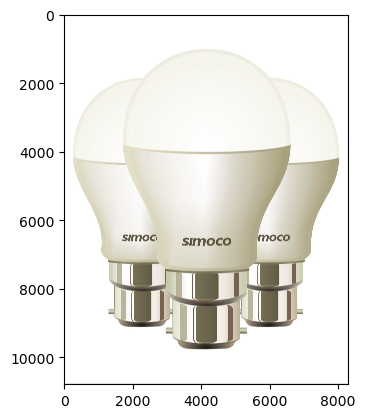

In [11]:
# listing des images trop grandes > 89 478 485 pix
max_pixel = 89478485
bigsize_list = []

for i in image_list:
    img = cv2.imread(path + i)
    size = img.size
    if size > max_pixel:
        bigsize_list.append(i)

        # Obtenir les dimensions
        height, width, channels = img.shape
        print("avant redimentionnement")
        print(f"{i} \nTaille : {img.shape[0]*img.shape[1]} pixels")
        print(f"Hauteur : {height}px")
        print(f"Largeur : {width}px")
        print(f"Nombre de canaux : {channels}")
        # Affichage de l'image
        plt.imshow(img)
        plt.show

Image redimensionnée : 
5518124b75d6c6dfee4c2e4c0cfa716a.jpg (10791, 8291, 3)
Taille : 89468181 pixels


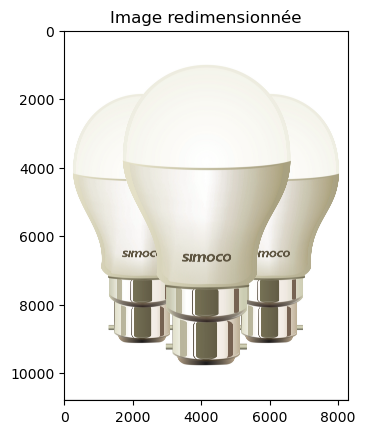

In [12]:
# redimensionnement des images trop grandes
# directement dans la base de données
for i in bigsize_list:
    bigsize = cv2.imread(path + i)
    height, width, channels = bigsize.shape
    scale = np.sqrt(max_pixel / (height * width))
    new_height = int(scale * height)
    new_width = int(scale * width)

    resized = cv2.resize(bigsize, (new_width, new_height))
    cv2.imwrite(path + i, resized)
    print(f"Image redimensionnée : \n{i} {resized.shape}")
    print(f"Taille : {resized.shape[0]*resized.shape[1]} pixels")
    plt.imshow(resized)
    plt.title("Image redimensionnée")
    plt.show()
bigsize_list = []

L'image :   
5518124b75d6c6dfee4c2e4c0cfa716a.jpg a été redimensionné  
de 93680328 à 89468181 px < 89478485 px

## Split train/test

In [13]:
# Split du DataFrame en train et test
train_df, test_df = train_test_split(
    image_df,
    test_size=0.2,  # 20% pour le test
    stratify=image_df["category"],  # conserver les proportions des classes
    random_state=42,
)
print("train :",len(train_df), ", test :",len(test_df))

train : 840 , test : 210


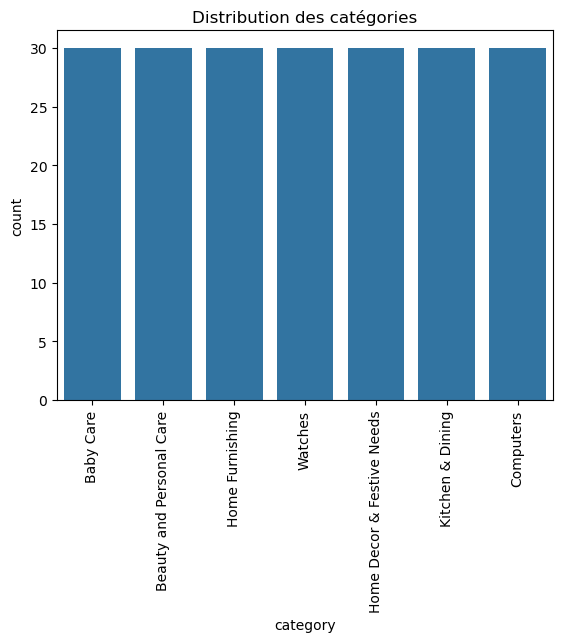

In [225]:
# Distribution des 7 catégories

sns.countplot(x=test_df["category"])
plt.title("Distribution des catégories")
plt.xticks(rotation=90)
plt.show()

## Nombre de classes

In [14]:
# Nombre de classes à prédire
n_classes = train_df["category"].nunique()
print("nombre de classes =", n_classes)

nombre de classes = 7


# CNN : VGG16 en Classification supervisée Transfert Learning

## Data augmentation

In [15]:
# TRAIN et VAL
# Définition des générateurs d'images avec normalisation et augmentation
train_datagen_vgg = ImageDataGenerator(
    width_shift_range=0.1,  # décalage
    height_shift_range=0.1,  # décalage
    horizontal_flip=True,  # Retournement vertical
    validation_split=0.20,
    preprocessing_function=preprocess_input,
)

# Création des flux d'images à partir des noms de fichiers
train_generator_vgg = train_datagen_vgg.flow_from_dataframe(
    dataframe=train_df,
    directory=path,
    x_col="image",
    y_col="category",
    target_size=(224, 224),
    keep_aspect_ratio=True,
    batch_size=32,
    class_mode="categorical",
    subset="training",
    seed=42,
)
val_generator_vgg = train_datagen_vgg.flow_from_dataframe(
    dataframe=train_df,
    directory=path,
    x_col="image",
    y_col="category",
    target_size=(224, 224),
    keep_aspect_ratio=True,
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    seed=42,
)


# TEST
# Définition du générateur d'images
test_datagen_vgg = ImageDataGenerator(
    #     rescale=1.0/255,
    validation_split=0,
    #preprocessing_function=preprocess_input,
)

# Générer des flux d'images à partir des noms de fichiers
test_generator_vgg = test_datagen_vgg.flow_from_dataframe(
    dataframe=test_df,
    directory=path,
    x_col="image",
    y_col="category",
    target_size=(224, 224),
    keep_aspect_ratio=True,
    batch_size=32,
    class_mode="categorical",
    subset=None,
    color_mode='rgb',
    shuffle=False,
    seed=42,
)

Found 672 validated image filenames belonging to 7 classes.
Found 168 validated image filenames belonging to 7 classes.
Found 210 validated image filenames belonging to 7 classes.


## Chargement et préparation de VGG-16 pré-entraîné

**Stratégie de Transfer Learning** (gel des couches)  
  
- **Feature Extraction** :  
utiliser un modèle pré-entraîné comme extracteur de caractéristiques
sans modifier ses poids et entraîner uniquement le classifieur final.  
- **Fine-Tuning partiel** :  
Réutiliser un modèle pré-entraîné,  
geler les premières couches qui capturent des caractéristiques générales,  
et réentraîner uniquement les dernières couches pour les adapter au nouveau problème.  
-  **Fine-Tuning complet** :  
Réutiliser un modèle pré-entraîné,  
puis réentraîner l'ensemble des couches sur le nouveau data set afin d'adapter complètement le modèle.  
***Face au nombre d'images disponibles (1050), nous choisirons la méthode "Feature Extraction"***

Compte tenu de la taille du dataset, nous utiliserons la méthode "Feature Extraction"  
Modification des couches fully-connected : layer.trainable = False

In [16]:
print("nombre de classe = ", n_classes)

# Chargement de VGG-16 pré-entraîné sur ImageNet et sans les couches fully-connected
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,  # suppression des couches fully-connected
    input_shape=(224, 224, 3)
)

# Méthode "Feature Extraction"
# Gèle des couches de base
for layer in vgg_base.layers:
    layer.trainable = False

# Ajout du classifieur pour les 7 classes
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

# Ajout de la nouvelle couche fully-connected pour la classification à 7 classes
predictions = Dense(n_classes, activation="softmax")(x)

# Définition du nouveau modèle
model_vgg = Model(inputs=vgg_base.input, outputs=predictions)

# Compilation du modèle
model_vgg.compile(
    optimizer= Adam(learning_rate=1e-4), #Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

nombre de classe =  7


## Callback

In [17]:
# Création du callback

# Sauvegarde du meilleur modèle rencontré pendant l'entraînement
model_vgg_best_path = "./model_vgg_best.keras"
checkpoint = ModelCheckpoint(
    model_vgg_best_path,
    mode="min",
    monitor="val_loss",
    verbose=1,
    save_best_only=True,
)
es = EarlyStopping(monitor="val_loss",
                   mode="min",
                   verbose=1,
                   patience=5,
                   # sauvegarde des meilleurs poids dans le dernier modèle en mémoire
                   restore_best_weights=True,
                  )

callbacks_list = [checkpoint, es]

In [18]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices("GPU")))

Num GPUs Available:  0




Pour éviter d'exécuter l'entrainement du modèle à chaque relance du notebook :

    Sauvegarde du modèle + historique
    Mise en RAW de la cellule d'entrainement du modèle + extraction de l'historique
    Chargement des sauvegardes pour poursuivre le notebook



## Entrainement

Sauvegardes du modèle :  
2 options   
- Sauvegarde du meilleur modèle (meilleurs poids)  
faite via callbacks et earlystopping : "model_vgg_best.keras"  
- Sauvegarde du dernier état du modèle à la fin de l’entraînement model_vgg.save("model_vgg.keras")  
pour obtenir le meilleur modèle, il faudra lui charger les poids du meilleur modèle. 


In [20]:
# Chargement du modèle
best_vgg16 = load_model("model_vgg_best.keras")
# vérification
best_vgg16.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,114,071 (57.66 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 266,256 (1.02 MB)

In [21]:
# Chargement de l'historique
score_history_vgg_df = pd.read_csv("score_history_vgg_df.csv")
# vérification
score_history_vgg_df

,Unnamed: 0,accuracy,loss,val_accuracy,val_loss
0,0,0.147321,9.096947,0.232143,3.816489
1,1,0.261905,6.405656,0.398810,2.764391
2,2,0.375000,4.866009,0.517857,2.143764
3,3,0.415179,4.079163,0.577381,1.861861
4,4,0.498512,3.172435,0.607143,1.642399
5,5,0.553571,2.602774,0.654762,1.608108
6,6,0.575893,2.269031,0.660714,1.550462
7,7,0.626488,2.325202,0.708333,1.436104
8,8,0.620536,1.942248,0.696429,1.460774
9,9,0.660714,1.606505,0.750000,1.340480


## Evaluation

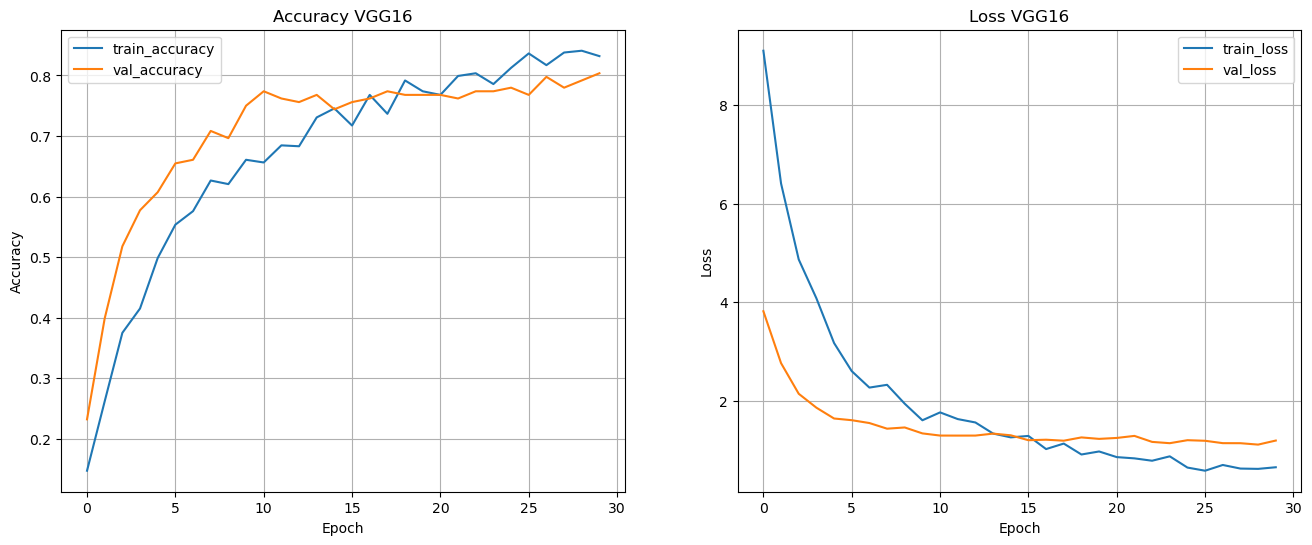

In [182]:
# Courbes Val_accuracy, val_loss et train_loss, val_loss

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(score_history_vgg_df["accuracy"], label="train_accuracy")
axes[0].plot(score_history_vgg_df["val_accuracy"], label="val_accuracy")
axes[0].grid()
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].set_title("Accuracy VGG16")

axes[1].plot(score_history_vgg_df["loss"], label="train_loss")
axes[1].plot(score_history_vgg_df["val_loss"], label="val_loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid()
axes[1].legend()
axes[1].set_title("Loss VGG16")


plt.show()

In [33]:
# Évaluation du meilleurs du modèle
scores_test_vgg = best_vgg16.evaluate(test_generator_vgg, verbose=1)
print("scores =  ", scores_test_vgg)
print(f" Test loss : {scores_test_vgg[0]:.2f}")
print(f" Test accuracy : {scores_test_vgg[1]*100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 75s 11s/step - accuracy: 0.6952 - loss: 1.8849
scores =   [1.8849000930786133, 0.6952381134033203]
 Test loss : 1.88
 Test accuracy : 69.52%


## Matrice

- y_pred_proba : Récupération de la probabilité qu'une image appartienne à une classe  
.predict donne un tableau (images, classes) chaque ligne représente une image et  
les colonnes représentent  les 7 classes.  
On a donc la probabilité que l'image appartienne à chaque classe.  
- y_pred : affectation de l'image à la classe la plus probable
- y_true : les vraies classes

In [34]:
# Prédictions probabilistes
y_pred_proba_vgg = best_vgg16.predict(test_generator_vgg)

# Classe prédite
y_pred_vgg = np.argmax(y_pred_proba_vgg, axis=1) # index de la valeur max

# Vraies classes
y_true_vgg = test_generator_vgg.classes

# Noms des classes
class_labels_vgg = list(test_generator_vgg.class_indices.keys())

7/7 ━━━━━━━━━━━━━━━━━━━━ 83s 12s/step


In [203]:
results_vgg_df = pd.DataFrame({
    "uniq_id": test_df["uniq_id"].values,
    "image": test_generator_vit.filenames,
    "true_label": y_true_vgg,
    "pred_label": y_pred_vgg,
    "confidence": np.max(y_pred_proba_vgg, axis=1)
})

results_vgg_df["correct"] = (
    results_vgg_df["true_label"] ==
    results_vgg_df["pred_label"]
)
results_vgg_df.head()

,uniq_id,image,true_label,pred_label,confidence,correct
0,3dfd14b667357e26ff6d66761cdc203f,3dfd14b667357e26ff6d66761cdc203f.jpg,0,0,0.998092,True
1,17a73d7c4b02ada2bfeed1115fed08a4,17a73d7c4b02ada2bfeed1115fed08a4.jpg,1,1,1.000000,True
2,597a9549a3e397d52dca62ee47b1f60a,597a9549a3e397d52dca62ee47b1f60a.jpg,4,0,0.779611,False
3,24e85c590481a7cedfe66597f253f2b2,24e85c590481a7cedfe66597f253f2b2.jpg,1,2,0.755273,False
4,59d964c38c787f829c6cfa5629e4df90,59d964c38c787f829c6cfa5629e4df90.jpg,1,1,1.000000,True


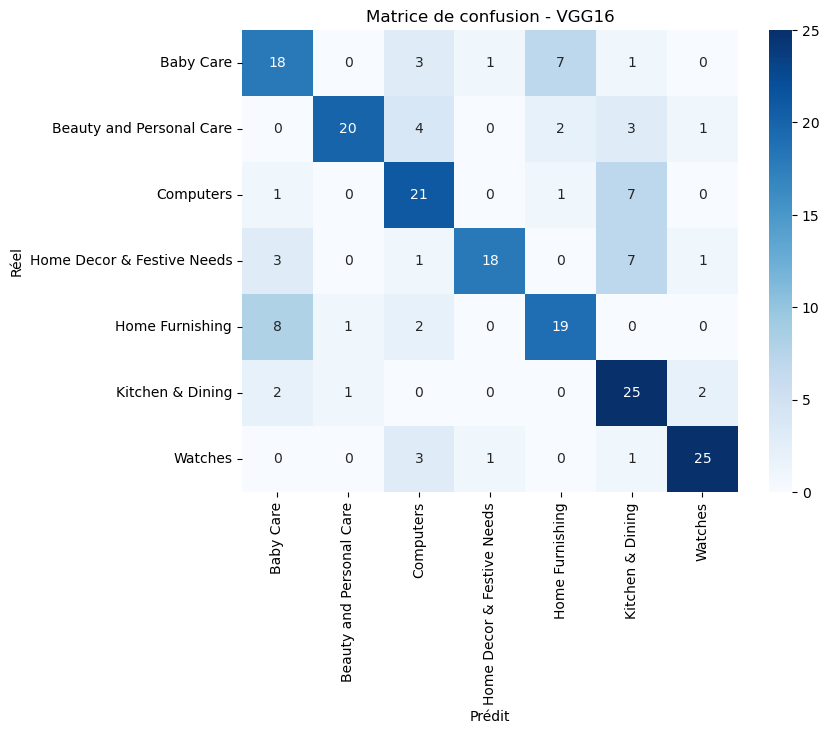

In [35]:
cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_vgg, annot=True, cmap="Blues",
            xticklabels=class_labels_vgg,
            yticklabels=class_labels_vgg,
           )
plt.title("Matrice de confusion - VGG16")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# Transformer : ViT en classification supervisée par transfert learning

## Data Augmentation

In [36]:
# TRAIN et VAL
# Définition des générateurs d'images train avec normalisation et augmentation
train_datagen_vit = ImageDataGenerator(
    rescale=1./255,
    width_shift_range=0.1,  # décalage
    height_shift_range=0.1,  # décalage
    horizontal_flip=True,  # Retournement vertical
    validation_split=0.20,
)

# Création des flux d'images à partir des noms de fichiers
train_generator_vit = train_datagen_vit.flow_from_dataframe(
    dataframe=train_df,
    directory=path,
    x_col="image",
    y_col="category",
    target_size=(224, 224),
    keep_aspect_ratio=True,
    batch_size=32,
    class_mode="categorical",
    subset="training",
    seed=42,
)
val_generator_vit = train_datagen_vit.flow_from_dataframe(
    dataframe=train_df,
    directory=path,
    x_col="image",
    y_col="category",
    target_size=(224, 224),
    keep_aspect_ratio=True,
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    seed=42,
)


# TEST
# Définition du générateur d'images test
test_datagen_vit = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0,
)

# Générer des flux d'images à partir des noms de fichiers
test_generator_vit = test_datagen_vit.flow_from_dataframe(
    dataframe=test_df,
    directory=path,
    x_col="image",
    y_col="category",
    target_size=(224, 224),
    keep_aspect_ratio=True,
    batch_size=32,
    class_mode="categorical",
    color_mode="rgb",
    shuffle=False,
    seed=42,
)

Found 672 validated image filenames belonging to 7 classes.
Found 168 validated image filenames belonging to 7 classes.
Found 210 validated image filenames belonging to 7 classes.


## Callback

In [37]:
model_vit_best_path = "./model_vit_best.keras"

checkpoint_vit = ModelCheckpoint(
    model_vit_best_path, # Nom du fichier enregistré
    mode="min",          # Recherche la valeur mini
    monitor="val_loss",  # Métrique d'évaluation
    verbose=1,           # Affichage des messages
    save_best_only=True, # Sauvegarde uniquement si amélioration
)

es_vit = EarlyStopping(
    monitor="val_loss",        # Métrique d'évaluation du EarlyStopping 
    mode="min",                # Recherche la valeur minimale
    verbose=1,                 # affichage des messages
    patience=5,                # Stop après 5 epoch si moins performant  
    restore_best_weights=True, # Recharge les poids du meilleur modèle
                               # dans le dernier exécuté (celui resté en mémoire)
)

callbacks_list_vit = [checkpoint_vit, es_vit]

## Chargement et préparation de ViT pré-entraîné

- **Feature Extraction** :  
utiliser un modèle pré-entraîné comme extracteur de caractéristiques
sans modifier ses poids et entraîner uniquement le classifieur final.  
- **Fine-Tuning partiel** :  
Réutiliser un modèle pré-entraîné,  
geler les premières couches qui capturent des caractéristiques générales,  
et réentraîner uniquement les dernières couches pour les adapter au nouveau problème.  
-  **Fine-Tuning complet** :  
Réutiliser un modèle pré-entraîné,  
puis réentraîner l'ensemble des couches sur le nouveau data set afin d'adapter complètement le modèle.  
***Face au nombre d'images disponibles (1050), nous choisirons la méthode "Feature Extraction"***

In [38]:
print("nombre de classes =", n_classes)

# Chargement du modèle ViT-B/16 pré-entraîné
vit_base = vit.vit_b16(
    image_size=224,       # Taille des images en entrée : 224x224
    activation="linear",  # Pas d'activation finale dans le backbone
    pretrained=True,      # Utilisation des poids pré-entraînés
    include_top=False,    # Suppression de la tête de classification d'origine
    pretrained_top=False, # Ne pas charger la tête ImageNet pré-entraînée
    classes=n_classes,    # Nombre de classes
)

# Méthode "Feature Extraction" :
# Feature Extraction :  gèle le backbone ViT
for layer in vit_base.layers:
    layer.trainable = False

# Ajout d'une nouvelle tête de classification adaptée aux 7 classes
x = vit_base.output
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
predictions = Dense(n_classes, activation="softmax")(x)

# Création du modèle final
model_vit = Model(inputs=vit_base.input, outputs=predictions)

# Compilation du modèle
model_vit.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Affichage de l'architecture complète du modèle
model_vit.summary()

nombre de classes = 7


C:\Users\Steeve\anaconda3\envs\OpenCV_env\lib\site-packages\vit_keras\utils.py:85: UserWarning: Resizing position embeddings from 24, 24 to 14, 14
  warnings.warn(


Model: "functional_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_38 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Conv2D)              │ (None, 14, 14, 768)    │       590,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 196, 768)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_token (ClassToken)        │ (None, 197, 768)       │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_posembed_input      │ (None, 197, 768)       │       151,296 │
│ (AddPositionEmbs)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_0      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_1      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_2      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_3      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_4      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_5      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_6      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_7      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_8      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_9      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │             

 Total params: 85,997,319 (328.05 MB)

 Trainable params: 198,663 (776.03 KB)

 Non-trainable params: 85,798,656 (327.30 MB)

## Entrainement ViT

In [39]:
# Chargement du modèle
model_vit_best = load_model("model_vit_best.keras",safe_mode=False)
# vérification
model_vit_best.summary()

C:\Users\Steeve\anaconda3\envs\OpenCV_env\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 394 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Conv2D)              │ (None, 14, 14, 768)    │       590,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 196, 768)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_token (ClassToken)        │ (None, 197, 768)       │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_posembed_input      │ (None, 197, 768)       │       151,296 │
│ (AddPositionEmbs)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_0      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_1      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_2      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_3      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_4      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_5      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_6      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_7      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_8      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │               │
│                                 │ None)]                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Transformer_encoderblock_9      │ [(None, 197, 768),     │     7,087,872 │
│ (TransformerBlock)              │ (None, 12, None,       │             

 Total params: 256,503,575 (978.48 MB)

 Trainable params: 85,253,127 (325.21 MB)

 Non-trainable params: 744,192 (2.84 MB)

 Optimizer params: 170,506,256 (650.43 MB)

In [40]:
# Chargement de l'historique
score_history_vit_df = pd.read_csv("score_history_vit_df.csv")
# vérification
score_history_vit_df

,Unnamed: 0,accuracy,loss,val_accuracy,val_loss
0,0,0.226190,2.356404,0.535714,1.459500
1,1,0.470238,1.574977,0.666667,1.043912
2,2,0.601190,1.206368,0.738095,0.864548
3,3,0.699405,0.973823,0.779762,0.756827
4,4,0.741071,0.801858,0.797619,0.669968
5,5,0.744048,0.725555,0.797619,0.647573
6,6,0.815476,0.610582,0.821429,0.604154
7,7,0.812500,0.610033,0.857143,0.577476
8,8,0.837798,0.526342,0.851190,0.564153
9,9,0.833333,0.527406,0.851190,0.555290


## Evaluation

In [42]:
# Évaluation du meilleurs du modèle
scores_test_vit = model_vit_best.evaluate(test_generator_vit, verbose=0)
print("scores =  ", scores_test_vit)
print(f" Test loss : {scores_test_vit[0]:.2f}")
print(f" Test accuracy : {scores_test_vit[1]*100:.2f}%")

scores =   [0.4977143704891205, 0.8333333134651184]
 Test loss : 0.50
 Test accuracy : 83.33%


In [172]:
score_history_vit_df

,Unnamed: 0,accuracy,loss,val_accuracy,val_loss
0,0,0.226190,2.356404,0.535714,1.459500
1,1,0.470238,1.574977,0.666667,1.043912
2,2,0.601190,1.206368,0.738095,0.864548
3,3,0.699405,0.973823,0.779762,0.756827
4,4,0.741071,0.801858,0.797619,0.669968
5,5,0.744048,0.725555,0.797619,0.647573
6,6,0.815476,0.610582,0.821429,0.604154
7,7,0.812500,0.610033,0.857143,0.577476
8,8,0.837798,0.526342,0.851190,0.564153
9,9,0.833333,0.527406,0.851190,0.555290


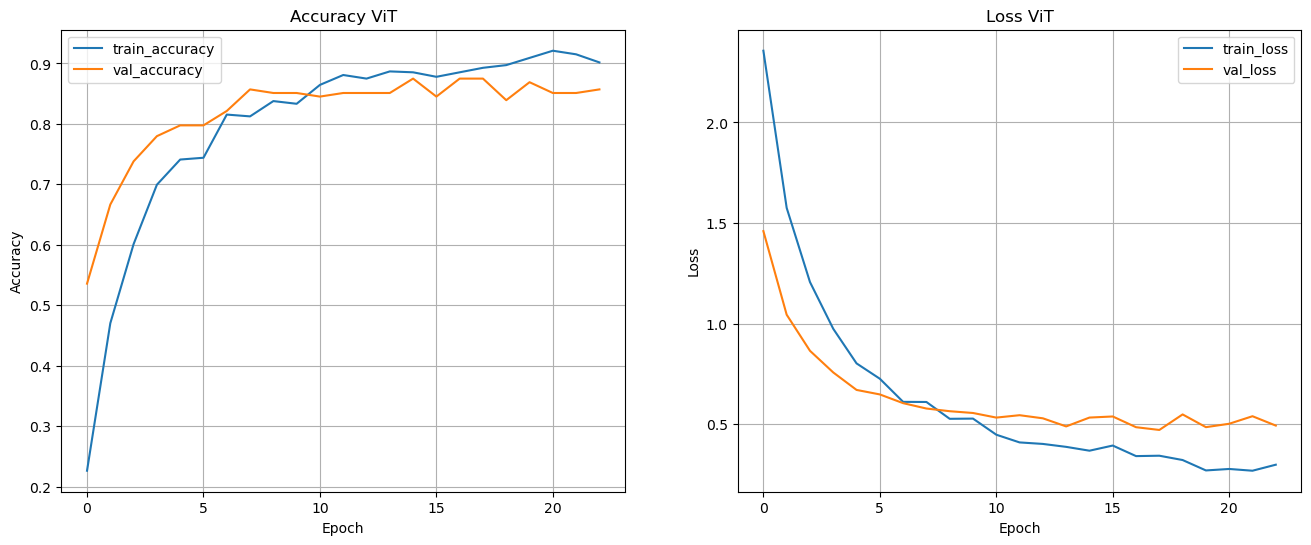

In [181]:
# Courbes Val_accuracy, val_loss et train_loss, val_loss

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(score_history_vit_df["accuracy"], label="train_accuracy")
axes[0].plot(score_history_vit_df["val_accuracy"], label="val_accuracy")
axes[0].grid()
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].set_title("Accuracy ViT")

axes[1].plot(score_history_vit_df["loss"], label="train_loss")
axes[1].plot(score_history_vit_df["val_loss"], label="val_loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid()
axes[1].legend()
axes[1].set_title("Loss ViT")

plt.show()

## Matrices

- y_pred_proba : Récupération de la probabilité qu'une image appartienne à une classe  
.predict donne un tableau (images, classes) chaque ligne représente une image et  
les colonnes représentent  les 7 classes.  
On a donc la probabilité que l'image appartienne à chaque classe.  
- y_pred : affectation de l'image à la classe la plus probable
- y_true : les vraies classes

In [45]:
# Prédictions probabilistes
y_pred_proba = model_vit_best.predict(test_generator_vit)

# Classe prédite
y_pred = np.argmax(y_pred_proba, axis=1) # index de la valeur max

# Vraies classes
y_true = test_generator_vit.classes

# Labels (noms des classes)
class_labels_vit = list(test_generator_vit.class_indices.keys())

7/7 ━━━━━━━━━━━━━━━━━━━━ 119s 17s/step


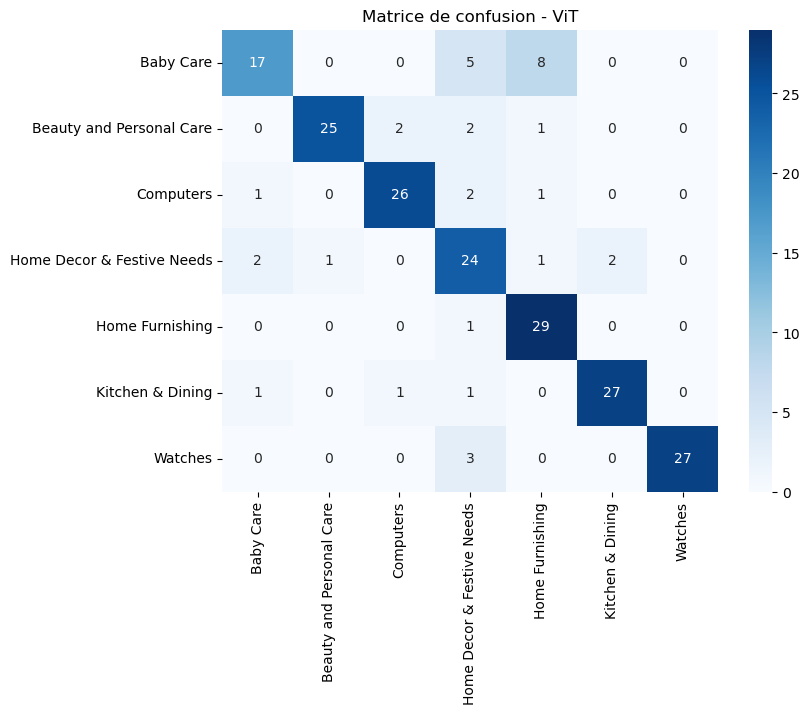

In [47]:
cm_vit = confusion_matrix(y_true, y_pred)
 
plt.figure(figsize=(8, 6))
sns.heatmap(cm_vit, annot=True, cmap="Blues",
            xticklabels=class_labels_vit,
            yticklabels=class_labels_vit,
           )
plt.title("Matrice de confusion - ViT")
plt.show()

## Attention Maps

## Patch

Découpage de l'image en patch (tokens visuels)  
ViT découpe l’image de 224 en 16 patches.  
224/16=14 donc 14×14=196 patches  
Le modèle transforme ensuite chaque patch en embedding.  
L’attention est calculée entre ces patches.  

Carte de chaleur indiquant les zones de l’image ciblées par le ViT.  
visualize.attention_map() produit une heatmap d’attention :  
Elle agrège les poids d’attention puis les projette sur l’image originale,  
afin de montrer les régions importantes pour la prédiction.

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


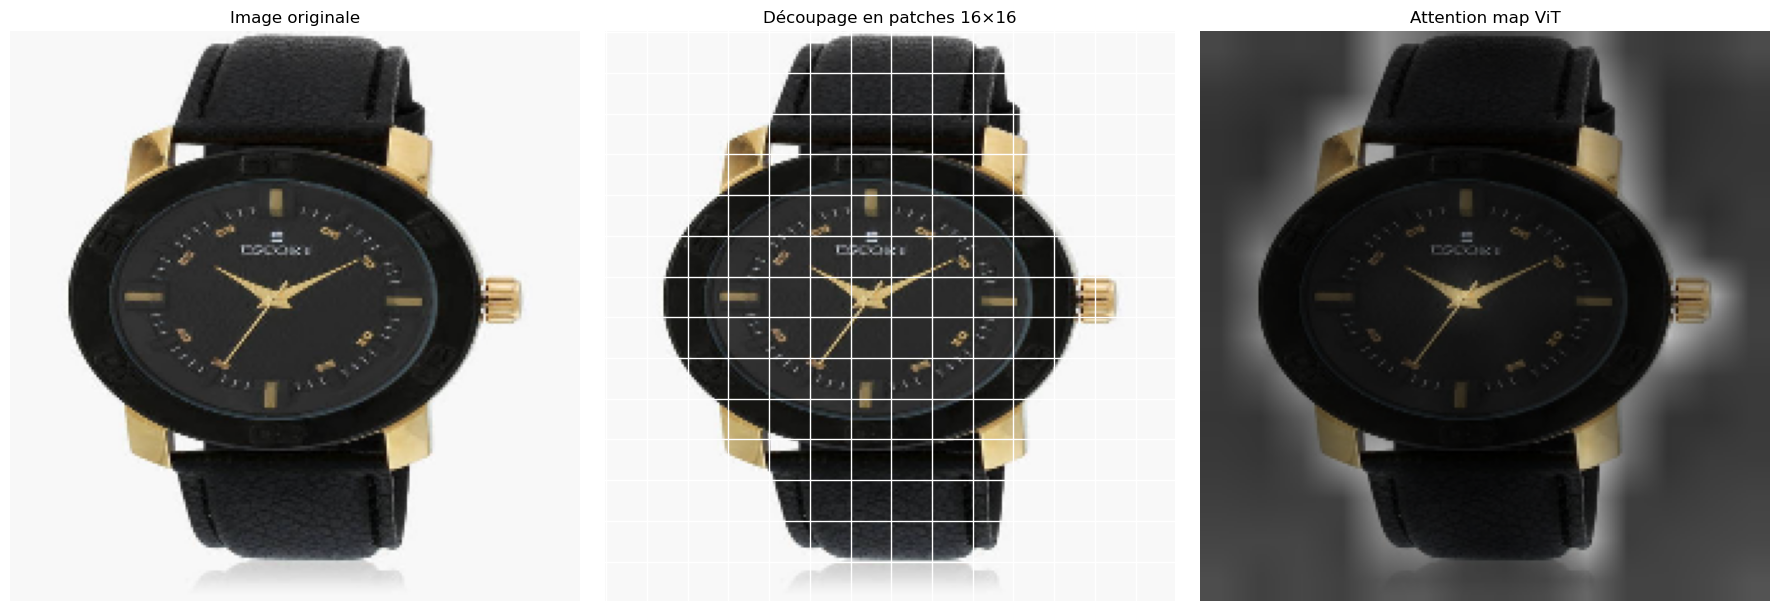

In [223]:
# Affichage d'une image test

image_path = path + image_list[15]

# Chargement image
image = utils.read(image_path, size=224)

# Attention map
attention_map = visualize.attention_map(
    model=model_vit_best,
    image=image
)
patch_size = 16


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# image 1 : originale
axes[0].imshow(image)

axes[0].set_title("Image originale")
axes[0].axis("off")

# image 2 : Grille patches
axes[1].imshow(image)

# lignes verticales
for x in range(0, 224, patch_size):
    axes[1].axvline(x, color="white", linewidth=1)

# lignes horizontales
for y in range(0, 224, patch_size):
    axes[1].axhline(y, color="white", linewidth=1)

axes[1].set_title("Découpage en patches 16×16")
axes[1].axis("off")

# image 3 : Attention map
axes[2].imshow(attention_map)
axes[2].set_title("Attention map ViT")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Exemple de mauvaise prédiction :

In [200]:
# Dataframe des résultats de la prédiction de test
results_vit_df = pd.DataFrame({
    "uniq_id": test_df["uniq_id"].values,
    "image": test_generator_vit.filenames,
    "true_label": y_true,
    "pred_label": y_pred,
    "confidence": np.max(y_pred_proba, axis=1)
})

results_vit_df["correct"] = (
    results_vit_df["true_label"] ==
    results_vit_df["pred_label"]
)
# affichage des mauvaises prédictions
results_vit_df[results_vit_df["correct"] == False].head()

In [207]:
results_vit_df[results_vit_df["correct"] == False].head()

,uniq_id,image,true_label,pred_label,confidence,correct
18,4589c5021b21525b4779260f7e86f355,4589c5021b21525b4779260f7e86f355.jpg,3,5,0.398882,False
26,2110699b945ae766c8b8112038ac58b9,2110699b945ae766c8b8112038ac58b9.jpg,5,3,0.322371,False
34,64d5d4a258243731dc7bbb1eef49ad74,64d5d4a258243731dc7bbb1eef49ad74.jpg,0,4,0.783259,False
38,f2f027ad6a6df617c9f125173da71e44,f2f027ad6a6df617c9f125173da71e44.jpg,0,3,0.541586,False
42,2cbad7ead8eb8dd92823b9f525c87b9c,2cbad7ead8eb8dd92823b9f525c87b9c.jpg,6,3,0.654909,False


In [222]:
test_df.loc[test_df["image"]=="be0f39341d771aac57084970f1ed6425.jpg" ,]

,uniq_id,product_name,product_category_tree,image,description,product_specifications,category
1044,be0f39341d771aac57084970f1ed6425,Wallmantra Medium Vinyl Stickers Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",be0f39341d771aac57084970f1ed6425.jpg,Buy Wallmantra Medium Vinyl Stickers Sticker f...,"{""product_specification""=>[{""key""=>""Number of ...",Baby Care


In [190]:
# Index des images mal classées
wrong_idx = np.where(y_pred != y_true)[0]

print(f"Nombre d'erreurs ViT : {len(wrong_idx)}")
print("Premiers index mal classés :", wrong_idx[:20])

Nombre d'erreurs ViT : 35
Premiers index mal classés : [ 18  26  34  38  42  54  55  57  64  65  75  86  91  97 102 111 116 120
 124 135 141 142 147 148 154 159]


In [221]:
image_path

'C:/Users/Steeve/Pictures/ImagesProjet6OCR/be0f39341d771aac57084970f1ed6425.jpg'

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


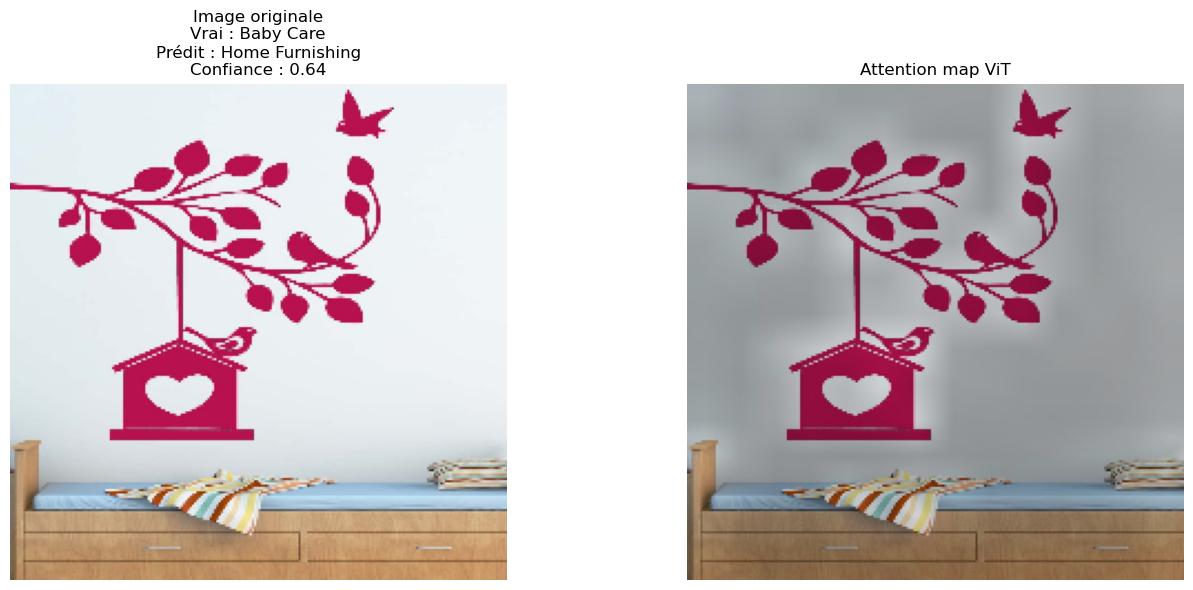

In [219]:
from vit_keras import utils, visualize
import matplotlib.pyplot as plt

idx = wrong_idx[6]

image_path = test_generator_vit.filepaths[idx]
image = utils.read(image_path, size=224)

attention_map = visualize.attention_map(
    model=model_vit_best,
    image=image
)

true_label = class_labels_vit[y_true[idx]]
pred_label = class_labels_vit[y_pred[idx]]
confidence = y_pred_proba[idx][y_pred[idx]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(image)
axes[0].axis("off")
axes[0].set_title(
    f"Image originale\nVrai : {true_label}\nPrédit : {pred_label}\nConfiance : {confidence:.2f}"
)

axes[1].imshow(image)
axes[1].imshow(attention_map, cmap="jet", alpha=0.5)
axes[1].axis("off")
axes[1].set_title("Attention map ViT")

plt.tight_layout()
plt.show()

# Comparaison VGG16 vs ViT

In [54]:
compare_df = pd.DataFrame({
    "Modèle": ["VGG16", "ViT"],
    "Accuracy test": [scores_test_vgg[1], scores_test_vit[1]],
    "Loss test": [scores_test_vgg[0], scores_test_vit[0]],
    #"Temps entraînement": [duration_vgg, duration_vit],
})
#compare_df["Tps en min"] = (compare_df["Temps entraînement"])/60
round(compare_df,2)

,Modèle,Accuracy test,Loss test
0,VGG16,0.70,1.88
1,ViT,0.83,0.50


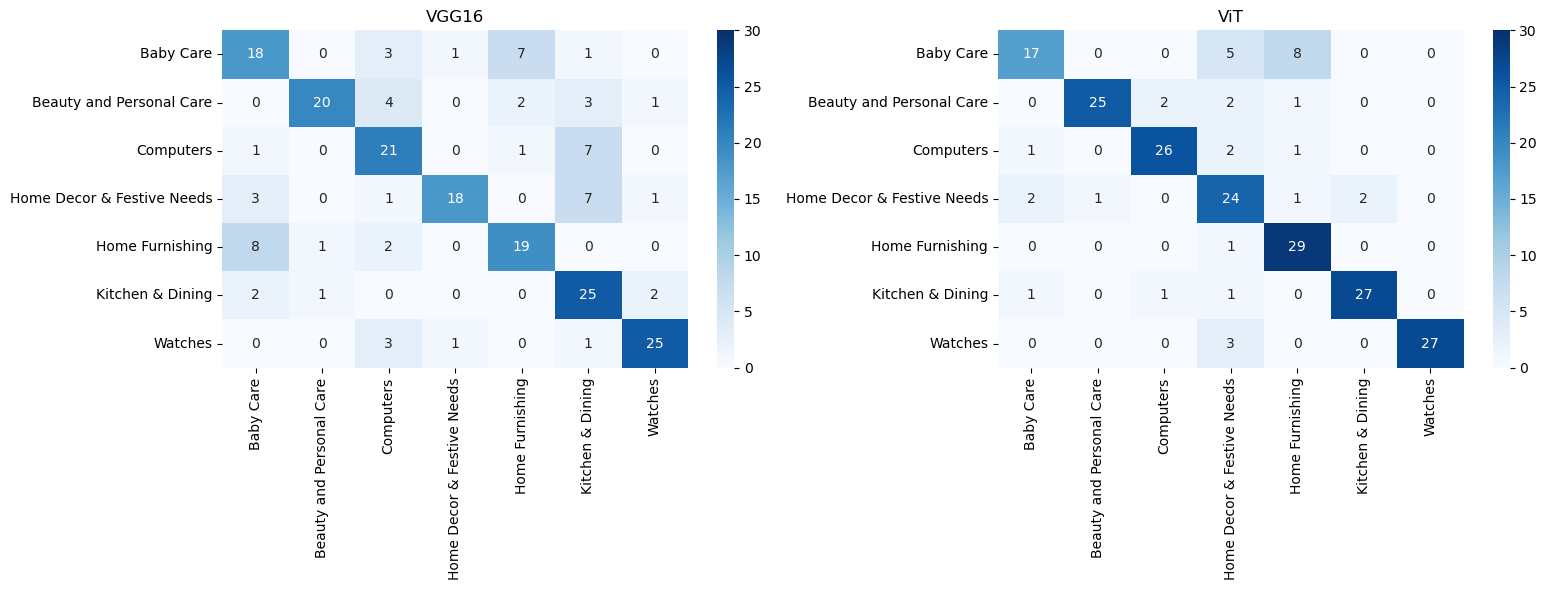

In [52]:
# Matrice de confusion

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_vgg, annot=True, fmt="d",
            xticklabels=class_labels_vgg,
            yticklabels=class_labels_vgg,
            cmap="Blues", ax=axes[0],
            vmax=30, vmin=0)
axes[0].set_title("VGG16")

sns.heatmap(cm_vit, annot=True, fmt="d",
            xticklabels=class_labels_vgg,
            yticklabels=class_labels_vgg,
            cmap="Blues", ax=axes[1],
            vmax=30, vmin=0)
axes[1].set_title("ViT")

plt.tight_layout()
plt.show()

Le jeu de test comporte 210 images, soit 30 images par catégorie.  
ViT fait moins d'erreurs  
- Ses principales erreurs viennent de produits de la catégorie "Baby Care" prédit  
comme étant des "Home Furnishing" ou "Home Decor & Festive Needs"
- d'où une légère sur-représentation de "Home Furnishing" et "Home Decor & Festive Needs"  
alors que Baby Care est sous représenté


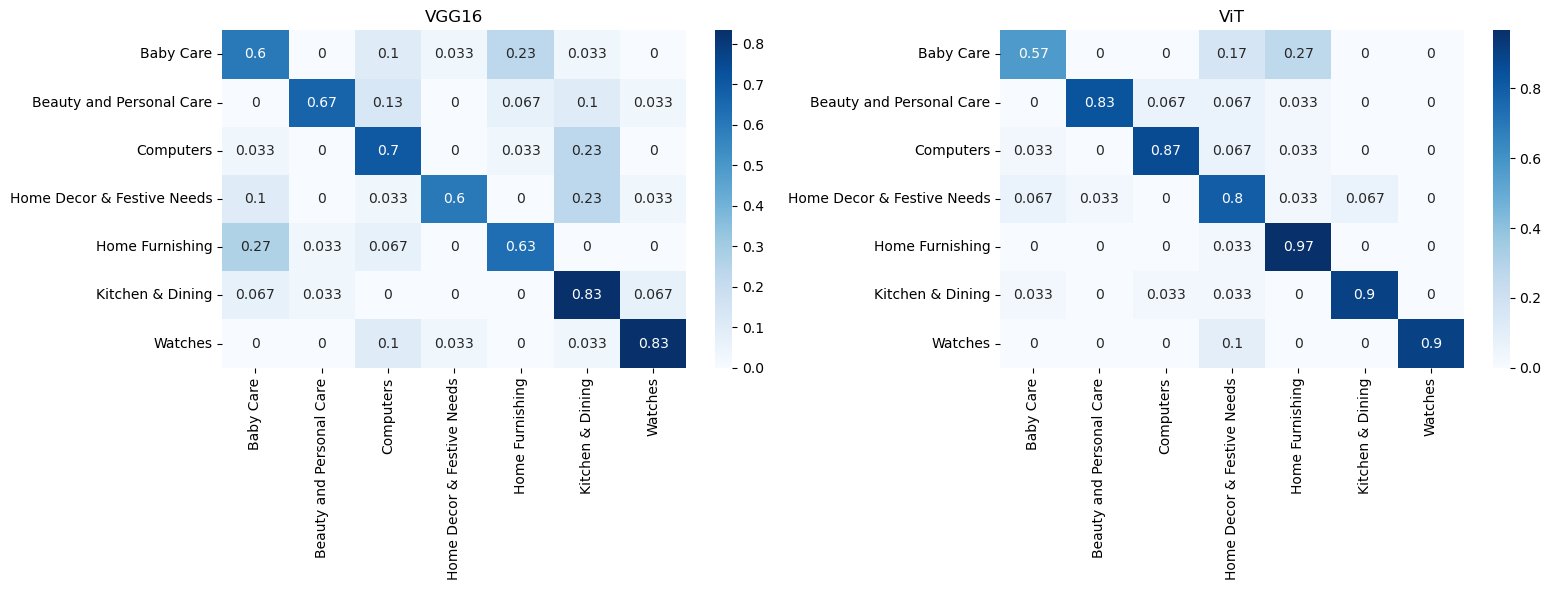

In [55]:
# Matrice de confusion normalisée

cm_vgg_norm = cm_vgg / cm_vgg.sum(axis=1, keepdims=True)
cm_vit_norm = cm_vit / cm_vit.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_vgg_norm, annot=True,
            xticklabels=class_labels_vgg,
            yticklabels=class_labels_vgg,
            cmap="Blues", ax=axes[0])
axes[0].set_title("VGG16")

sns.heatmap(cm_vit_norm, annot=True,
            xticklabels=class_labels_vit,
            yticklabels=class_labels_vit,
            cmap="Blues", ax=axes[1])
axes[1].set_title("ViT")

plt.tight_layout()
plt.show()